# B. Two-site Hubbard model with Qiskit Nature

This notebook reproduces the open two-site Hubbard Hamiltonian from `01_two_site_hubbard_ps.ipynb` using:

1. `FermiHubbardModel` for the second-quantized Hamiltonian;
2. `JordanWignerMapper` for the qubit Hamiltonian;
3. Qiskit's packaged `VQE` with a particle- and spin-preserving `UCCSD` ansatz.

The notebook is an executable validation contract. It requires agreement with the first-principles reference at four levels: every Pauli coefficient, the full matrix and spectra, independently constructed observables, and the VQE ground state. Any failed comparison raises an assertion immediately.

In [1]:
import itertools
import warnings
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse import SparseEfficiencyWarning

from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import Statevector
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.hamiltonians import FermiHubbardModel
from qiskit_nature.second_q.hamiltonians.lattices import (
    BoundaryCondition,
    LineLattice,
)
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.operators import FermionicOp

warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)
np.set_printoptions(precision=8, suppress=True)

for package in ["qiskit", "qiskit-nature", "qiskit-algorithms"]:
    print(f"{package:18s} {version(package)}")

qiskit             2.5.2
qiskit-nature      0.8.0
qiskit-algorithms  0.4.0


## 1. Model and ordering convention

We use exactly the Step A Hamiltonian

$$
H=-t\sum_{\sigma}(c_{0\sigma}^\dagger c_{1\sigma}+c_{1\sigma}^\dagger c_{0\sigma})
+U\sum_{i=0}^1 n_{i\uparrow}n_{i\downarrow},
$$

with open boundaries, $t=1$, $U=4$, and reference mode order

$$[0\uparrow,1\uparrow,0\downarrow,1\downarrow].$$

`FermiHubbardModel` natively emits site-interleaved modes $[0\uparrow,0\downarrow,1\uparrow,1\downarrow]$ (even indices are spin-up, odd indices spin-down). We therefore swap modes 1 and 2 with `permute_indices([0, 2, 1, 3])` before mapping. This is a basis-convention alignment, not a physical transformation. Qiskit Pauli labels and the reference labels are both printed as $q_3q_2q_1q_0$.

In [2]:
N_SITES = 2
N_ORBITALS = 2 * N_SITES
DIM = 2**N_ORBITALS
t = 1.0
U = 4.0
ATOL = 1e-10

def occupations(index, n_orbitals=N_ORBITALS):
    return tuple((index >> p) & 1 for p in range(n_orbitals))

def ket_label(index):
    return "|" + "".join(map(str, occupations(index))) + "⟩"

## 2. Independent Step A reference

The comparison target below uses only the explicit Fock-space sign rule from Step A. It does not call Qiskit Nature. Reconstructing the small reference here keeps this notebook executable on its own while preserving an independent implementation path.

In [3]:
def annihilation_matrix(p):
    matrix = np.zeros((DIM, DIM), dtype=complex)
    for column in range(DIM):
        occ = occupations(column)
        if occ[p]:
            row = column ^ (1 << p)
            matrix[row, column] = (-1) ** sum(occ[:p])
    return matrix

annihilators = [annihilation_matrix(p) for p in range(N_ORBITALS)]
creators = [op.conj().T for op in annihilators]
number_ops = [creators[p] @ annihilators[p] for p in range(N_ORBITALS)]

zero = np.zeros((DIM, DIM), dtype=complex)
hopping_ref = sum(
    (creators[left] @ annihilators[right] + creators[right] @ annihilators[left]
     for left, right in [(0, 1), (2, 3)]),
    start=zero,
)
double_occupancy_ref = number_ops[0] @ number_ops[2] + number_ops[1] @ number_ops[3]
H_ref = -t * hopping_ref + U * double_occupancy_ref
N_ref = sum(number_ops)

Sz0 = 0.5 * (number_ops[0] - number_ops[2])
Sz1 = 0.5 * (number_ops[1] - number_ops[3])
Sp0, Sm0 = creators[0] @ annihilators[2], creators[2] @ annihilators[0]
Sp1, Sm1 = creators[1] @ annihilators[3], creators[3] @ annihilators[1]
spin_correlation_ref = Sz0 @ Sz1 + 0.5 * (Sp0 @ Sm1 + Sm0 @ Sp1)

assert np.allclose(H_ref, H_ref.conj().T, atol=ATOL)
assert np.allclose(H_ref @ N_ref - N_ref @ H_ref, 0, atol=ATOL)
print("✓ Independent reference is Hermitian and conserves particle number")

✓ Independent reference is Hermitian and conserves particle number


## 3. `FermiHubbardModel` and mode alignment

The edge weight is `-t` because `FermiHubbardModel` uses the lattice edge weight directly as the hopping coefficient. The on-site lattice potential is zero; the Hubbard repulsion is supplied separately as `onsite_interaction=U`.

In [4]:
lattice = LineLattice(
    num_nodes=N_SITES,
    edge_parameter=-t,
    onsite_parameter=0.0,
    boundary_condition=BoundaryCondition.OPEN,
)
model = FermiHubbardModel(lattice=lattice, onsite_interaction=U)
H_fermionic_site_order = model.second_q_op().simplify()
H_fermionic = H_fermionic_site_order.permute_indices([0, 2, 1, 3]).simplify()

print("Native site-interleaved operator:")
print(H_fermionic_site_order)
print("\nSpin-blocked operator used for comparison:")
print(H_fermionic)

Native site-interleaved operator:
Fermionic Operator
number spin orbitals=4, number terms=6
  (-1+0j) * ( +_0 -_2 )
+ (1+0j) * ( -_0 +_2 )
+ (-1+0j) * ( +_1 -_3 )
+ (1+0j) * ( -_1 +_3 )
+ (4+0j) * ( +_0 -_0 +_1 -_1 )
+ (4+0j) * ( +_2 -_2 +_3 -_3 )

Spin-blocked operator used for comparison:
Fermionic Operator
number spin orbitals=4, number terms=6
  (-1+0j) * ( +_0 -_1 )
+ (1+0j) * ( -_0 +_1 )
+ (-1+0j) * ( +_2 -_3 )
+ (1+0j) * ( -_2 +_3 )
+ (4+0j) * ( +_0 -_0 +_2 -_2 )
+ (4+0j) * ( +_1 -_1 +_3 -_3 )


## 4. `JordanWignerMapper`: term-by-term agreement

We independently decompose the Step A matrix using $h_P=2^{-4}\operatorname{Tr}(P^\dagger H)$, then compare its dictionary of nonzero Pauli coefficients with Qiskit Nature's mapped `SparsePauliOp`. Equality of the dense matrices alone would not catch a label-reporting or coefficient-collection mistake, so both checks are required.

In [5]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}

def pauli_matrix(label):
    result = PAULI[label[0]]
    for symbol in label[1:]:
        result = np.kron(result, PAULI[symbol])
    return result

def reference_pauli_dict(operator, atol=ATOL):
    terms = {}
    for symbols in itertools.product("IXYZ", repeat=N_ORBITALS):
        label = "".join(symbols)
        coefficient = np.trace(pauli_matrix(label) @ operator) / DIM
        if abs(coefficient) > atol:
            terms[label] = complex(coefficient)
    return terms

def qiskit_pauli_dict(operator, atol=ATOL):
    return {
        label: complex(coefficient)
        for label, coefficient in operator.simplify(atol=atol).to_list()
        if abs(coefficient) > atol
    }

mapper = JordanWignerMapper()
H_qiskit_op = mapper.map(H_fermionic).simplify()
reference_terms = reference_pauli_dict(H_ref)
qiskit_terms = qiskit_pauli_dict(H_qiskit_op)

print(f"{'Pauli':<8} {'reference':>14} {'Qiskit Nature':>16} {'difference':>14}")
for label in sorted(reference_terms.keys() | qiskit_terms.keys()):
    ref = reference_terms.get(label, 0.0).real
    qiskit_value = qiskit_terms.get(label, 0.0).real
    print(f"{label:<8} {ref:>14.8f} {qiskit_value:>16.8f} {qiskit_value-ref:>+14.2e}")

assert reference_terms.keys() == qiskit_terms.keys()
for label in reference_terms:
    assert np.isclose(reference_terms[label], qiskit_terms[label], atol=ATOL)
print(f"\n✓ All {len(reference_terms)} nonzero Pauli terms agree")

Pauli         reference    Qiskit Nature     difference
IIII         2.00000000       2.00000000      +0.00e+00
IIIZ        -1.00000000      -1.00000000      +0.00e+00
IIXX        -0.50000000      -0.50000000      +0.00e+00
IIYY        -0.50000000      -0.50000000      +0.00e+00
IIZI        -1.00000000      -1.00000000      +0.00e+00
IZII        -1.00000000      -1.00000000      +0.00e+00
IZIZ         1.00000000       1.00000000      +0.00e+00
XXII        -0.50000000      -0.50000000      +0.00e+00
YYII        -0.50000000      -0.50000000      +0.00e+00
ZIII        -1.00000000      -1.00000000      +0.00e+00
ZIZI         1.00000000       1.00000000      +0.00e+00

✓ All 11 nonzero Pauli terms agree


## 5. Matrix and spectrum agreement

We compare the complete $16\times16$ operator and its full Fock-space spectrum. We then separately compare the physically relevant six-dimensional $N=2$ spectrum and the analytic ground energy

$$E_0=\frac{U-\sqrt{U^2+16t^2}}{2}.$$.

In [6]:
H_qiskit = H_qiskit_op.to_matrix()
assert np.allclose(H_qiskit, H_ref, atol=ATOL)

full_spectrum_ref = np.linalg.eigvalsh(H_ref)
full_spectrum_qiskit = np.linalg.eigvalsh(H_qiskit)
assert np.allclose(full_spectrum_qiskit, full_spectrum_ref, atol=ATOL)

half_filling = [i for i in range(DIM) if sum(occupations(i)) == 2]
H_half_ref = H_ref[np.ix_(half_filling, half_filling)]
H_half_qiskit = H_qiskit[np.ix_(half_filling, half_filling)]
energies_ref, eigenvectors_ref = np.linalg.eigh(H_half_ref)
energies_qiskit = np.linalg.eigvalsh(H_half_qiskit)
assert np.allclose(energies_qiskit, energies_ref, atol=ATOL)

E_exact = energies_ref[0]
E_analytic = (U - np.sqrt(U**2 + 16 * t**2)) / 2
assert np.isclose(E_exact, E_analytic, atol=ATOL)

psi_exact = np.zeros(DIM, dtype=complex)
psi_exact[half_filling] = eigenvectors_ref[:, 0]

print("full spectrum (16 states):")
print(full_spectrum_qiskit)
print("\nN=2 spectrum (6 states):")
print(energies_qiskit)
print(f"\nexact ground energy = {E_exact:.12f}")
print("✓ Dense matrix, full spectrum, N=2 spectrum, and analytic energy agree")

full spectrum (16 states):
[-1.         -1.         -0.82842712  0.          0.          0.
  0.          1.          1.          3.          3.          4.
  4.82842712  5.          5.          8.        ]

N=2 spectrum (6 states):
[-0.82842712  0.          0.          0.          4.          4.82842712]

exact ground energy = -0.828427124746
✓ Dense matrix, full spectrum, N=2 spectrum, and analytic energy agree


## 6. Observable operators

We construct total double occupancy $D$ and $\mathbf S_0\cdot\mathbf S_1$ directly as `FermionicOp` objects in the aligned spin-blocked order. Before using their expectation values, we require their mapped matrices to equal the independent Step A matrices.

In [7]:
def fermionic_term(label):
    return FermionicOp({label: 1.0}, num_spin_orbitals=N_ORBITALS)

n_fermionic = [fermionic_term(f"+_{p} -_{p}") for p in range(N_ORBITALS)]
Sp0_f, Sm0_f = fermionic_term("+_0 -_2"), fermionic_term("+_2 -_0")
Sp1_f, Sm1_f = fermionic_term("+_1 -_3"), fermionic_term("+_3 -_1")

double_occupancy_f = (n_fermionic[0] @ n_fermionic[2] + n_fermionic[1] @ n_fermionic[3]).simplify()
spin_correlation_f = (
    0.25 * ((n_fermionic[0] - n_fermionic[2]) @ (n_fermionic[1] - n_fermionic[3]))
    + 0.5 * (Sp0_f @ Sm1_f + Sm0_f @ Sp1_f)
).simplify()

double_occupancy_q = mapper.map(double_occupancy_f).simplify()
spin_correlation_q = mapper.map(spin_correlation_f).simplify()

assert np.allclose(double_occupancy_q.to_matrix(), double_occupancy_ref, atol=ATOL)
assert np.allclose(spin_correlation_q.to_matrix(), spin_correlation_ref, atol=ATOL)

def expectation(state, operator):
    return float(np.real(np.vdot(state, operator @ state)))

D_exact = expectation(psi_exact, double_occupancy_ref)
S_exact = expectation(psi_exact, spin_correlation_ref)
print(f"total double occupancy = {D_exact:.10f}")
print(f"<S_0 · S_1>           = {S_exact:.10f}")
print("✓ Both Qiskit observable matrices agree with the reference")

total double occupancy = 0.1464466094
<S_0 · S_1>           = -0.6401650429
✓ Both Qiskit observable matrices agree with the reference


## 7. Qiskit VQE
Start from a reference state, apply parameterized rotations within an allowed subspace, and let VQE optimize the rotation angles.

`HartreeFock(2, (1, 1), mapper)` prepares one spin-up and one spin-down fermion. `UCCSD` preserves those particle counts, so VQE searches the intended half-filled $N_\uparrow=N_\downarrow=1$ sector rather than the full Fock space. This matters because the unconstrained global ground state of the four-mode operator need not belong to $N=2$.

We use two UCCSD repetitions. For this small product-form ansatz, one repetition can settle above the exact ground energy; two repetitions reproducibly represent the target state. `StatevectorEstimator` makes the energy evaluations deterministic and noiseless. ($\left<P\right>$ is calculated exactly from the simulated statevector.) 
- No finite shots, so there is no statistical sampling error.
- No device noise, because no physical or noisy simulated hardware is used.

#### What is UCCSD doing here?
$|\psi(\boldsymbol\theta)\rangle=U_{\mathrm{UCCSD}}(\boldsymbol\theta)\,
|\psi_{\mathrm{HF}}\rangle =
\prod_k e^{\theta_k(\tau_k-\tau_k^\dagger)}
|\psi_{\mathrm{HF}}\rangle.$

This plays the same role as the $|\psi(\boldsymbol\theta)\rangle=
R_3(\theta_3)R_2(\theta_2)R_1(\theta_1)|1010\rangle$ in the previous notebook.

Each excitation operator $\tau_k$ connects determinants. For example, a single excitation might connect
$|1010\rangle \longleftrightarrow |0110\rangle,$ 
while a double excitation might connect
$|1010\rangle \longleftrightarrow |0101\rangle.$
Within the two-dimensional subspace connected by an excitation, the exponential acts like a rotation:
$
e^{\theta(\tau-\tau^\dagger)}
|a\rangle
=
\cos\theta\,|a\rangle
+
\sin\theta\,|b\rangle,
$ up to sign conventions.

In [8]:
num_particles = (1, 1)
initial_state = HartreeFock(
    num_spatial_orbitals=N_SITES,
    num_particles=num_particles,
    qubit_mapper=mapper,
)
ansatz = UCCSD(
    num_spatial_orbitals=N_SITES,
    num_particles=num_particles,
    qubit_mapper=mapper,
    reps=2,
    initial_state=initial_state,
)

history = []
def record_evaluation(evaluation_count, parameters, energy, metadata):
    history.append(float(energy))

rng = np.random.default_rng(7)
initial_point = 0.2 * rng.standard_normal(ansatz.num_parameters)
vqe = VQE(
    estimator=StatevectorEstimator(),
    ansatz=ansatz,
    optimizer=SLSQP(maxiter=1000, ftol=1e-12),
    initial_point=initial_point,
    callback=record_evaluation,
)
vqe_result = vqe.compute_minimum_eigenvalue(H_qiskit_op)

optimal_circuit = ansatz.assign_parameters(vqe_result.optimal_parameters)
psi_vqe = Statevector.from_instruction(optimal_circuit)
E_vqe = float(np.real(vqe_result.eigenvalue))
fidelity = abs(np.vdot(psi_exact, psi_vqe.data)) ** 2
N_vqe = expectation(psi_vqe.data, N_ref)

print(f"ansatz parameters = {ansatz.num_parameters}")
print(f"energy evaluations = {len(history)}")
print(f"E_VQE              = {E_vqe:.12f}")
print(f"E_exact            = {E_exact:.12f}")
print(f"energy error       = {E_vqe-E_exact:+.3e}")
print(f"state fidelity     = {fidelity:.12f}")
print(f"<N>                = {N_vqe:.12f}")

assert E_vqe >= E_exact - ATOL
assert abs(E_vqe - E_exact) < 1e-8
assert fidelity > 1 - 1e-8
assert np.isclose(N_vqe, 2.0, atol=ATOL)
print("✓ Qiskit VQE agrees with exact diagonalization")

ansatz parameters = 6
energy evaluations = 138
E_VQE              = -0.828427124746
E_exact            = -0.828427124746
energy error       = +4.330e-15
state fidelity     = 1.000000000000
<N>                = 2.000000000000
✓ Qiskit VQE agrees with exact diagonalization


In [9]:
observables = [
    ("double occupancy", double_occupancy_ref, double_occupancy_q),
    ("spin correlation", spin_correlation_ref, spin_correlation_q),
]
print(f"{'observable':<24} {'reference ED':>14} {'Qiskit ED':>14} {'Qiskit VQE':>14} {'VQE-ref':>14}")
for name, reference_matrix, qiskit_operator in observables:
    reference_value = expectation(psi_exact, reference_matrix)
    qiskit_ed_value = float(Statevector(psi_exact).expectation_value(qiskit_operator).real)
    vqe_value = float(psi_vqe.expectation_value(qiskit_operator).real)
    print(
        f"{name:<24} {reference_value:>14.10f} {qiskit_ed_value:>14.10f} "
        f"{vqe_value:>14.10f} {vqe_value-reference_value:>+14.2e}"
    )
    assert np.isclose(qiskit_ed_value, reference_value, atol=ATOL)
    assert np.isclose(vqe_value, reference_value, atol=1e-8)
print("\n✓ Exact and VQE observable values agree with Step A")

observable                 reference ED      Qiskit ED     Qiskit VQE        VQE-ref
double occupancy           0.1464466094   0.1464466094   0.1464466082      -1.19e-09
spin correlation          -0.6401650429  -0.6401650429  -0.6401650438      -8.89e-10

✓ Exact and VQE observable values agree with Step A


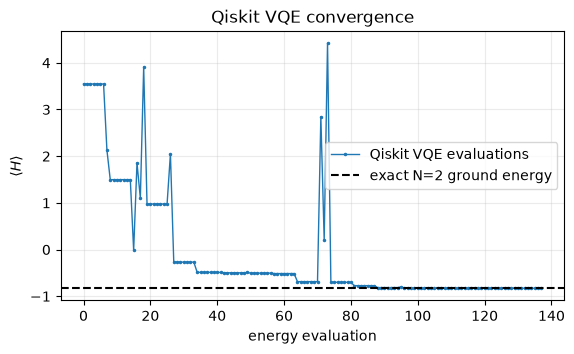

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(history, marker=".", ms=3, lw=1, label="Qiskit VQE evaluations")
ax.axhline(E_exact, color="black", ls="--", label="exact N=2 ground energy")
ax.set(
    xlabel="energy evaluation",
    ylabel=r"$\langle H\rangle$",
    title="Qiskit VQE convergence",
)
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 8. Validation summary

The complete Step B chain is now checked:

- `FermiHubbardModel` constructs the open two-site fermionic model;
- an explicit mode permutation aligns its native site-interleaved order with Step A's spin-blocked order;
- `JordanWignerMapper` agrees on every nonzero Pauli label and coefficient;
- the $16\times16$ matrices, full spectra, and $N=2$ spectra agree;
- mapped double occupancy and spin-correlation operators equal their first-principles matrices;
- Qiskit VQE reaches the exact energy and state, preserves $N=2$, and reproduces both observables.

Because these cells contain assertions, a clean `Run All` is the acceptance test for Step B.